In [1]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.feature_selection import RFE
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

In [2]:
# Read the data from local machine.
data = pd.read_csv("D:/Thesis/Model Apply 2017/CICIDS2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

In [3]:
selected_columns = [' Destination Port', 'Total Length of Fwd Packets','Bwd Packet Length Max',' Fwd Header Length',' Average Packet Size',' Avg Fwd Segment Size',' Avg Bwd Segment Size',' Fwd Header Length.1',' Subflow Fwd Bytes','Init_Win_bytes_forward',' Init_Win_bytes_backward',' act_data_pkt_fwd',' Label']

In [4]:
data = data[selected_columns]
data.head()

,Destination Port,Total Length of Fwd Packets,Bwd Packet Length Max,Fwd Header Length,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,Label
0,54865,12,0,40,9.0,6.0,0.0,40,12,33,-1,1,BENIGN
1,55054,6,6,20,9.0,6.0,6.0,20,6,29,256,0,BENIGN
2,55055,6,6,20,9.0,6.0,6.0,20,6,29,256,0,BENIGN
3,46236,6,6,20,9.0,6.0,6.0,20,6,31,329,0,BENIGN
4,54863,12,0,40,9.0,6.0,0.0,40,12,32,-1,1,BENIGN


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0    Destination Port            225745 non-null  int64  
 1   Total Length of Fwd Packets  225745 non-null  int64  
 2   Bwd Packet Length Max        225745 non-null  int64  
 3    Fwd Header Length           225745 non-null  int64  
 4    Average Packet Size         225745 non-null  float64
 5    Avg Fwd Segment Size        225745 non-null  float64
 6    Avg Bwd Segment Size        225745 non-null  float64
 7    Fwd Header Length.1         225745 non-null  int64  
 8    Subflow Fwd Bytes           225745 non-null  int64  
 9   Init_Win_bytes_forward       225745 non-null  int64  
 10   Init_Win_bytes_backward     225745 non-null  int64  
 11   act_data_pkt_fwd            225745 non-null  int64  
 12   Label                       225745 non-null  object 
dtyp

In [7]:
# replace +ve and -ve infinity with NaN
# data.replace([np.inf, -np.inf], np.nan, inplace=True)

In [7]:
# Identify rows with NaN or infinity values
rows_with_nan = data.isnull().any(axis=1)
rows_with_inf = data.isin([np.inf, -np.inf]).any(axis=1)

# Combine both conditions to identify rows with NaN or infinity values
rows_to_delete = rows_with_nan | rows_with_inf

# Keep track of the deleted rows
deleted_rows = data[rows_to_delete]

# Remove rows with NaN or infinity values
data_cleaned = data[~rows_to_delete]

print("\nDeleted Rows:")
pd.set_option("display.max_columns", len(deleted_rows.columns))

# Display the entire DataFrame
print(deleted_rows)

# Reset the display option to its default (if needed)
pd.reset_option("display.max_columns")


Deleted Rows:
Empty DataFrame
Columns: [ Destination Port, Total Length of Fwd Packets, Bwd Packet Length Max,  Fwd Header Length,  Average Packet Size,  Avg Fwd Segment Size,  Avg Bwd Segment Size,  Fwd Header Length.1,  Subflow Fwd Bytes, Init_Win_bytes_forward,  Init_Win_bytes_backward,  act_data_pkt_fwd,  Label]
Index: []


In [10]:
data = data_cleaned
data.head()

,Destination Port,Total Length of Fwd Packets,Bwd Packet Length Max,Fwd Header Length,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,Label
0,54865,12,0,40,9.0,6.0,0.0,40,12,33,-1,1,BENIGN
1,55054,6,6,20,9.0,6.0,6.0,20,6,29,256,0,BENIGN
2,55055,6,6,20,9.0,6.0,6.0,20,6,29,256,0,BENIGN
3,46236,6,6,20,9.0,6.0,6.0,20,6,31,329,0,BENIGN
4,54863,12,0,40,9.0,6.0,0.0,40,12,32,-1,1,BENIGN


In [11]:
# drop missing values
data.dropna(inplace=True)

In [12]:
# See the mean,standard deviation,min, max of each column.
data.describe()

,Destination Port,Total Length of Fwd Packets,Bwd Packet Length Max,Fwd Header Length,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd
count,225745.00000,225745.000000,225745.000000,225745.000000,225745.000000,225745.000000,225745.000000,225745.000000,225745.000000,225745.000000,225745.000000,225745.000000
mean,8879.61946,939.463346,2735.585147,111.522718,574.568843,164.826715,890.536849,111.522718,939.463346,4247.436922,601.048635,3.311497
std,19754.64740,3249.403484,3705.123460,375.790727,626.096202,504.892965,1120.324921,375.790727,3249.403484,8037.781019,4319.720339,12.270018
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.000000
25%,80.00000,26.000000,0.000000,64.000000,7.500000,6.000000,0.000000,64.000000,26.000000,229.000000,-1.000000,1.000000
50%,80.00000,30.000000,99.000000,72.000000,141.000000,8.666667,92.000000,72.000000,30.000000,256.000000,126.000000,2.000000
75%,80.00000,63.000000,5840.000000,100.000000,1291.888889,32.000000,1934.500000,100.000000,63.000000,8192.000000,229.000000,4.000000
max,65532.00000,183012.000000,11680.000000,39396.000000,2528.000000,3867.000000,5800.500000,39396.000000,183012.000000,65535.000000,65535.000000,1931.000000


In [14]:
# To see how many record fall in each classes.
data[' Label'].value_counts()

 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

In [15]:
from plotly.offline import init_notebook_mode, iplot, plot
import plotly as py
import plotly.express as px
init_notebook_mode(connected=True)
import plotly.graph_objs as go

fig = go.Figure(data=[
    go.Bar(name='DDoS', 
           y=data[" Label"].value_counts().values[0:1],
           x=['DDoS'],
           text = data[" Label"].value_counts()[0:1],
           orientation='v',
           textposition='outside',),
    go.Bar(name='BENIGN', 
           y=data[" Label"].value_counts().values[1:2],
           x=['BENIGN'],
           text = data[" Label"].value_counts()[1:2],
           orientation='v',
           textposition='outside',)
])
# Change the bar mode
fig.update_layout(
                  width=800,
                  height=600,
                  title=f'Class Distribution',
                  yaxis_title='Number of attacks',
                  xaxis_title='Attack Name',)
iplot(fig)

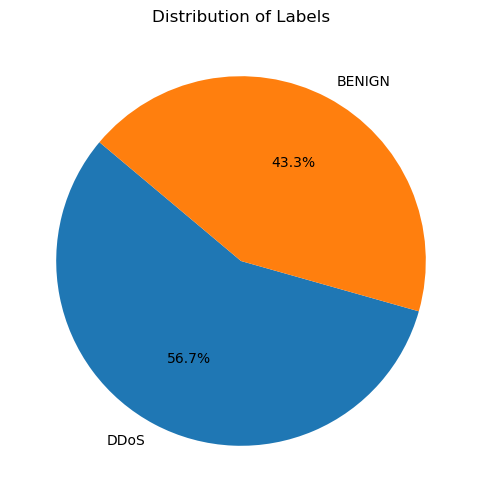

In [17]:
import matplotlib.pyplot as plt
# Assuming data is a pandas DataFrame
data1 = {'Label': ['DDoS', 'BENIGN'],
        'Count': [128025, 97686]}

# Plotting the pie chart
plt.figure(figsize=(6, 6))
plt.pie(data1['Count'], labels=data1['Label'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Labels')
plt.show()

In [18]:
x = data.iloc[:,:-1]
y = data[' Label']

In [67]:
# Apply the train test split.
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y, random_state=25)

# Data Transformation

In [39]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [40]:
# Apply the label encoding to the target cloumn.
le = LabelEncoder()
y_train = le.fit_transform(np.ravel(y_train))
y_test = le.fit_transform(np.ravel(y_test))

In [23]:
x = scaler.fit_transform(x)
y = le.fit_transform(y)

# Apply Model

# Gradient Boosting.

In [24]:
gradientBoosting = GradientBoostingClassifier()

In [25]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

In [26]:
gbc_grid = RandomizedSearchCV(estimator=gradientBoosting,param_distributions=param_grid,cv=5,verbose=2,n_jobs=-1)

In [27]:
gbc_grid.fit(x,y)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.5],
                                        'max_depth': [3, 5, 7],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200],
                                        'subsample': [0.8, 1.0]},
                   verbose=2)

In [28]:
print(gbc_grid.best_params_)

{'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 7, 'learning_rate': 0.5}


In [29]:
bestModel = gbc_grid.best_estimator_

In [31]:
print(gbc_grid.best_score_)

0.9996899156127489


In [41]:
bestModel.fit(x_train,y_train)

GradientBoostingClassifier(learning_rate=0.5, max_depth=7, min_samples_leaf=2,
                           min_samples_split=5, n_estimators=200)

In [42]:
yPredHyperGradientBoosting = bestModel.predict(x_test)

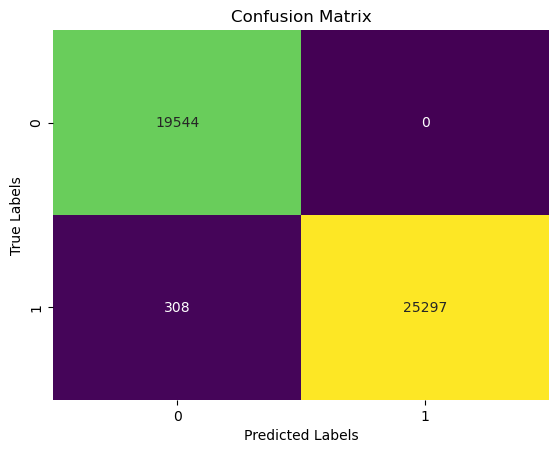

In [43]:
confMat = confusion_matrix(y_test,yPredHyperGradientBoosting)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [36]:
print(format(classification_report(y_test,yPredHyperGradientBoosting)))

              precision    recall  f1-score   support

           0       0.80      0.99      0.88     19544
           1       0.99      0.81      0.89     25605

    accuracy                           0.89     45149
   macro avg       0.89      0.90      0.89     45149
weighted avg       0.91      0.89      0.89     45149



In [37]:
print("f1 Score {}".format(f1_score(y_test,yPredHyperGradientBoosting)))
print("Recall Score {}".format(recall_score(y_test,yPredHyperGradientBoosting)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredHyperGradientBoosting)))
print("Precision Score {}".format(precision_score(y_test,yPredHyperGradientBoosting)))

f1 Score 0.8902077151335311
Recall Score 0.8084358523725835
Accuracy Score 0.8869077941925624
Precision Score 0.9903832352519019


# Random Forest

In [44]:
randomForest = RandomForestClassifier()

In [45]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

In [46]:
rf_grid = RandomizedSearchCV(estimator=randomForest,param_distributions=param_grid,cv=5,verbose=2,n_jobs=-1)

In [47]:
rf_grid.fit(x,y)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   verbose=2)

In [48]:
print(rf_grid.best_params_)

{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}


In [55]:
print(rf_grid.best_score_)

0.9997253538284347


In [56]:
bestModelRandomForest = rf_grid.best_estimator_

In [68]:
bestModelRandomForest.fit(x_train,y_train)

RandomForestClassifier(max_features='log2')

In [69]:
yPredHyperRandomForest = bestModelRandomForest.predict(x_test)

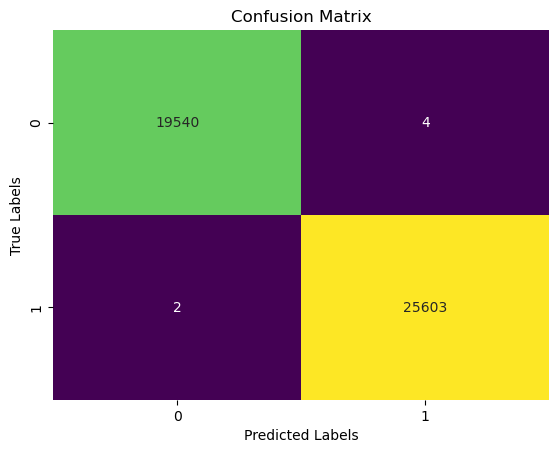

In [70]:
confMat = confusion_matrix(y_test,yPredHyperRandomForest)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [71]:
print(format(classification_report(y_test,yPredHyperRandomForest)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19544
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149



In [72]:
print("f1 Score {}".format(f1_score(y_test,yPredHyperRandomForest)))
print("Recall Score {}".format(recall_score(y_test,yPredHyperRandomForest)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredHyperRandomForest)))
print("Precision Score {}".format(precision_score(y_test,yPredHyperRandomForest)))

f1 Score 0.9998828399593845
Recall Score 0.9999218902558095
Accuracy Score 0.9998671066911781
Precision Score 0.9998437927129301


# CatBoosting.

In [73]:
catBoosting = CatBoostClassifier()

In [74]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}

In [75]:
cb_grid = RandomizedSearchCV(estimator=catBoosting, param_distributions=param_grid, cv=5, scoring='accuracy')

In [76]:
cb_grid.fit(x,y)

0:	learn: 0.6506923	total: 216ms	remaining: 3m 36s
1:	learn: 0.6148131	total: 238ms	remaining: 1m 58s
2:	learn: 0.5788914	total: 258ms	remaining: 1m 25s
3:	learn: 0.5464747	total: 277ms	remaining: 1m 9s
4:	learn: 0.5140533	total: 297ms	remaining: 59.1s
5:	learn: 0.4922680	total: 316ms	remaining: 52.3s
6:	learn: 0.4611289	total: 335ms	remaining: 47.5s
7:	learn: 0.4367227	total: 355ms	remaining: 44s
8:	learn: 0.4183647	total: 374ms	remaining: 41.2s
9:	learn: 0.4012293	total: 394ms	remaining: 39s
10:	learn: 0.3772525	total: 413ms	remaining: 37.2s
11:	learn: 0.3622159	total: 437ms	remaining: 36s
12:	learn: 0.3433282	total: 461ms	remaining: 35s
13:	learn: 0.3296252	total: 486ms	remaining: 34.3s
14:	learn: 0.3161843	total: 506ms	remaining: 33.2s
15:	learn: 0.2958593	total: 525ms	remaining: 32.3s
16:	learn: 0.2845115	total: 544ms	remaining: 31.5s
17:	learn: 0.2682613	total: 563ms	remaining: 30.7s
18:	learn: 0.2535428	total: 582ms	remaining: 30s
19:	learn: 0.2386048	total: 601ms	remaining: 29.

167:	learn: 0.0052746	total: 4.2s	remaining: 20.8s
168:	learn: 0.0052527	total: 4.25s	remaining: 20.9s
169:	learn: 0.0052274	total: 4.46s	remaining: 21.8s
170:	learn: 0.0051759	total: 4.51s	remaining: 21.9s
171:	learn: 0.0051525	total: 4.57s	remaining: 22s
172:	learn: 0.0051301	total: 4.6s	remaining: 22s
173:	learn: 0.0050660	total: 4.64s	remaining: 22s
174:	learn: 0.0050045	total: 4.67s	remaining: 22s
175:	learn: 0.0049754	total: 4.7s	remaining: 22s
176:	learn: 0.0049464	total: 4.73s	remaining: 22s
177:	learn: 0.0049235	total: 4.76s	remaining: 22s
178:	learn: 0.0048920	total: 4.8s	remaining: 22s
179:	learn: 0.0048473	total: 4.84s	remaining: 22.1s
180:	learn: 0.0048142	total: 4.88s	remaining: 22.1s
181:	learn: 0.0047773	total: 4.9s	remaining: 22s
182:	learn: 0.0047448	total: 4.93s	remaining: 22s
183:	learn: 0.0047192	total: 4.96s	remaining: 22s
184:	learn: 0.0046985	total: 5s	remaining: 22s
185:	learn: 0.0046686	total: 5.03s	remaining: 22s
186:	learn: 0.0046388	total: 5.06s	remaining: 

330:	learn: 0.0026401	total: 8.69s	remaining: 17.6s
331:	learn: 0.0026353	total: 8.71s	remaining: 17.5s
332:	learn: 0.0026324	total: 8.73s	remaining: 17.5s
333:	learn: 0.0026278	total: 8.75s	remaining: 17.4s
334:	learn: 0.0026226	total: 8.78s	remaining: 17.4s
335:	learn: 0.0026132	total: 8.79s	remaining: 17.4s
336:	learn: 0.0026078	total: 8.81s	remaining: 17.3s
337:	learn: 0.0025971	total: 8.83s	remaining: 17.3s
338:	learn: 0.0025923	total: 8.85s	remaining: 17.3s
339:	learn: 0.0025872	total: 8.87s	remaining: 17.2s
340:	learn: 0.0025833	total: 8.89s	remaining: 17.2s
341:	learn: 0.0025790	total: 8.91s	remaining: 17.1s
342:	learn: 0.0025722	total: 8.93s	remaining: 17.1s
343:	learn: 0.0025655	total: 8.96s	remaining: 17.1s
344:	learn: 0.0025621	total: 8.97s	remaining: 17s
345:	learn: 0.0025528	total: 8.99s	remaining: 17s
346:	learn: 0.0025454	total: 9.02s	remaining: 17s
347:	learn: 0.0025403	total: 9.04s	remaining: 16.9s
348:	learn: 0.0025352	total: 9.05s	remaining: 16.9s
349:	learn: 0.0025

498:	learn: 0.0017814	total: 12.2s	remaining: 12.2s
499:	learn: 0.0017814	total: 12.2s	remaining: 12.2s
500:	learn: 0.0017814	total: 12.2s	remaining: 12.2s
501:	learn: 0.0017788	total: 12.2s	remaining: 12.1s
502:	learn: 0.0017745	total: 12.3s	remaining: 12.1s
503:	learn: 0.0017721	total: 12.3s	remaining: 12.1s
504:	learn: 0.0017700	total: 12.3s	remaining: 12.1s
505:	learn: 0.0017598	total: 12.4s	remaining: 12.1s
506:	learn: 0.0017586	total: 12.4s	remaining: 12.1s
507:	learn: 0.0017520	total: 12.5s	remaining: 12.1s
508:	learn: 0.0017511	total: 12.5s	remaining: 12.1s
509:	learn: 0.0017509	total: 12.5s	remaining: 12s
510:	learn: 0.0017510	total: 12.6s	remaining: 12s
511:	learn: 0.0017502	total: 12.6s	remaining: 12s
512:	learn: 0.0017490	total: 12.6s	remaining: 12s
513:	learn: 0.0017430	total: 12.7s	remaining: 12s
514:	learn: 0.0017396	total: 12.7s	remaining: 12s
515:	learn: 0.0017357	total: 12.7s	remaining: 11.9s
516:	learn: 0.0017292	total: 12.8s	remaining: 11.9s
517:	learn: 0.0017292	to

665:	learn: 0.0015163	total: 16.8s	remaining: 8.43s
666:	learn: 0.0015161	total: 16.8s	remaining: 8.4s
667:	learn: 0.0015145	total: 16.8s	remaining: 8.37s
668:	learn: 0.0015136	total: 16.9s	remaining: 8.35s
669:	learn: 0.0015086	total: 16.9s	remaining: 8.32s
670:	learn: 0.0015072	total: 16.9s	remaining: 8.29s
671:	learn: 0.0015072	total: 16.9s	remaining: 8.26s
672:	learn: 0.0015070	total: 16.9s	remaining: 8.23s
673:	learn: 0.0015070	total: 17s	remaining: 8.2s
674:	learn: 0.0015009	total: 17s	remaining: 8.18s
675:	learn: 0.0015009	total: 17s	remaining: 8.15s
676:	learn: 0.0015010	total: 17s	remaining: 8.12s
677:	learn: 0.0015010	total: 17s	remaining: 8.09s
678:	learn: 0.0014958	total: 17.1s	remaining: 8.07s
679:	learn: 0.0014955	total: 17.1s	remaining: 8.04s
680:	learn: 0.0014942	total: 17.1s	remaining: 8.01s
681:	learn: 0.0014935	total: 17.1s	remaining: 7.99s
682:	learn: 0.0014936	total: 17.2s	remaining: 7.96s
683:	learn: 0.0014898	total: 17.2s	remaining: 7.94s
684:	learn: 0.0014898	to

...

434:	learn: 0.0009488	total: 29.8s	remaining: 38.7s
435:	learn: 0.0009488	total: 29.8s	remaining: 38.6s
436:	learn: 0.0009488	total: 29.9s	remaining: 38.5s
437:	learn: 0.0009488	total: 29.9s	remaining: 38.4s
438:	learn: 0.0009488	total: 30s	remaining: 38.3s
439:	learn: 0.0009488	total: 30s	remaining: 38.2s
440:	learn: 0.0009488	total: 30s	remaining: 38.1s
441:	learn: 0.0009488	total: 30.1s	remaining: 38s
442:	learn: 0.0009488	total: 30.1s	remaining: 37.9s
443:	learn: 0.0009488	total: 30.1s	remaining: 37.8s
444:	learn: 0.0009488	total: 30.2s	remaining: 37.6s
445:	learn: 0.0009488	total: 30.2s	remaining: 37.5s
446:	learn: 0.0009488	total: 30.3s	remaining: 37.5s
447:	learn: 0.0009488	total: 30.3s	remaining: 37.4s
448:	learn: 0.0009488	total: 30.4s	remaining: 37.3s
449:	learn: 0.0009488	total: 30.4s	remaining: 37.2s
450:	learn: 0.0009488	total: 30.4s	remaining: 37.1s
451:	learn: 0.0009488	total: 30.5s	remaining: 37s
452:	learn: 0.0009488	total: 30.5s	remaining: 36.8s
453:	learn: 0.0009488	

595:	learn: 0.0009488	total: 37.4s	remaining: 25.3s
596:	learn: 0.0009488	total: 37.5s	remaining: 25.3s
597:	learn: 0.0009488	total: 37.5s	remaining: 25.2s
598:	learn: 0.0009488	total: 37.6s	remaining: 25.2s
599:	learn: 0.0009488	total: 37.7s	remaining: 25.1s
600:	learn: 0.0009488	total: 37.7s	remaining: 25.1s
601:	learn: 0.0009488	total: 37.8s	remaining: 25s
602:	learn: 0.0009488	total: 37.9s	remaining: 24.9s
603:	learn: 0.0009488	total: 37.9s	remaining: 24.9s
604:	learn: 0.0009488	total: 38s	remaining: 24.8s
605:	learn: 0.0009488	total: 38s	remaining: 24.7s
606:	learn: 0.0009488	total: 38.1s	remaining: 24.7s
607:	learn: 0.0009488	total: 38.1s	remaining: 24.6s
608:	learn: 0.0009488	total: 38.2s	remaining: 24.5s
609:	learn: 0.0009488	total: 38.3s	remaining: 24.5s
610:	learn: 0.0009488	total: 38.3s	remaining: 24.4s
611:	learn: 0.0009488	total: 38.4s	remaining: 24.3s
612:	learn: 0.0009488	total: 38.5s	remaining: 24.3s
613:	learn: 0.0009488	total: 38.5s	remaining: 24.2s
614:	learn: 0.0009

754:	learn: 0.0009488	total: 46.1s	remaining: 15s
755:	learn: 0.0009488	total: 46.1s	remaining: 14.9s
756:	learn: 0.0009488	total: 46.2s	remaining: 14.8s
757:	learn: 0.0009488	total: 46.2s	remaining: 14.8s
758:	learn: 0.0009488	total: 46.3s	remaining: 14.7s
759:	learn: 0.0009488	total: 46.4s	remaining: 14.7s
760:	learn: 0.0009488	total: 46.5s	remaining: 14.6s
761:	learn: 0.0009488	total: 46.6s	remaining: 14.5s
762:	learn: 0.0009488	total: 46.6s	remaining: 14.5s
763:	learn: 0.0009488	total: 46.7s	remaining: 14.4s
764:	learn: 0.0009488	total: 46.8s	remaining: 14.4s
765:	learn: 0.0009488	total: 46.8s	remaining: 14.3s
766:	learn: 0.0009488	total: 46.9s	remaining: 14.2s
767:	learn: 0.0009488	total: 47s	remaining: 14.2s
768:	learn: 0.0009488	total: 47s	remaining: 14.1s
769:	learn: 0.0009488	total: 47.1s	remaining: 14.1s
770:	learn: 0.0009488	total: 47.2s	remaining: 14s
771:	learn: 0.0009488	total: 47.3s	remaining: 14s
772:	learn: 0.0009488	total: 47.3s	remaining: 13.9s
773:	learn: 0.0009488	

913:	learn: 0.0009488	total: 57.1s	remaining: 5.37s
914:	learn: 0.0009488	total: 57.2s	remaining: 5.31s
915:	learn: 0.0009488	total: 57.2s	remaining: 5.25s
916:	learn: 0.0009488	total: 57.3s	remaining: 5.18s
917:	learn: 0.0009488	total: 57.3s	remaining: 5.12s
918:	learn: 0.0009488	total: 57.4s	remaining: 5.06s
919:	learn: 0.0009488	total: 57.4s	remaining: 4.99s
920:	learn: 0.0009488	total: 57.5s	remaining: 4.93s
921:	learn: 0.0009488	total: 57.6s	remaining: 4.87s
922:	learn: 0.0009488	total: 57.6s	remaining: 4.81s
923:	learn: 0.0009488	total: 57.7s	remaining: 4.75s
924:	learn: 0.0009488	total: 57.7s	remaining: 4.68s
925:	learn: 0.0009488	total: 57.8s	remaining: 4.62s
926:	learn: 0.0009488	total: 57.9s	remaining: 4.55s
927:	learn: 0.0009488	total: 57.9s	remaining: 4.49s
928:	learn: 0.0009488	total: 58s	remaining: 4.43s
929:	learn: 0.0009488	total: 58.1s	remaining: 4.37s
930:	learn: 0.0009488	total: 58.1s	remaining: 4.3s
931:	learn: 0.0009488	total: 58.1s	remaining: 4.24s
932:	learn: 0.0

RandomizedSearchCV(cv=5,
                   estimator=<catboost.core.CatBoostClassifier object at 0x0000021BE59A1D50>,
                   param_distributions={'depth': [4, 6, 8],
                                        'l2_leaf_reg': [1, 3, 5, 7, 9],
                                        'learning_rate': [0.01, 0.05, 0.1]},
                   scoring='accuracy')

In [77]:
print(cb_grid.best_params_)

{'learning_rate': 0.05, 'l2_leaf_reg': 9, 'depth': 8}


In [78]:
print(cb_grid.best_score_)

0.9997209240514741


In [79]:
bestModelCatBoosting = cb_grid.best_estimator_

In [80]:
bestModelCatBoosting.fit(x_train,y_train)

0:	learn: 0.5424377	total: 37.3ms	remaining: 37.2s
1:	learn: 0.3995928	total: 74.5ms	remaining: 37.2s
2:	learn: 0.2926191	total: 110ms	remaining: 36.4s
3:	learn: 0.2153618	total: 144ms	remaining: 35.9s
4:	learn: 0.1583727	total: 179ms	remaining: 35.7s
5:	learn: 0.1184574	total: 216ms	remaining: 35.9s
6:	learn: 0.0884257	total: 258ms	remaining: 36.6s
7:	learn: 0.0665727	total: 303ms	remaining: 37.6s
8:	learn: 0.0508138	total: 342ms	remaining: 37.7s
9:	learn: 0.0396259	total: 380ms	remaining: 37.7s
10:	learn: 0.0311051	total: 419ms	remaining: 37.6s
11:	learn: 0.0250806	total: 466ms	remaining: 38.4s
12:	learn: 0.0201976	total: 514ms	remaining: 39s
13:	learn: 0.0165804	total: 554ms	remaining: 39s
14:	learn: 0.0138152	total: 592ms	remaining: 38.9s
15:	learn: 0.0115046	total: 628ms	remaining: 38.6s
16:	learn: 0.0097308	total: 665ms	remaining: 38.4s
17:	learn: 0.0082966	total: 708ms	remaining: 38.6s
18:	learn: 0.0071904	total: 750ms	remaining: 38.7s
19:	learn: 0.0063267	total: 788ms	remaining

162:	learn: 0.0010852	total: 6.16s	remaining: 31.6s
163:	learn: 0.0010850	total: 6.2s	remaining: 31.6s
164:	learn: 0.0010850	total: 6.23s	remaining: 31.5s
165:	learn: 0.0010850	total: 6.26s	remaining: 31.5s
166:	learn: 0.0010849	total: 6.3s	remaining: 31.4s
167:	learn: 0.0010850	total: 6.33s	remaining: 31.4s
168:	learn: 0.0010849	total: 6.37s	remaining: 31.3s
169:	learn: 0.0010848	total: 6.41s	remaining: 31.3s
170:	learn: 0.0010851	total: 6.45s	remaining: 31.3s
171:	learn: 0.0010848	total: 6.49s	remaining: 31.2s
172:	learn: 0.0010854	total: 6.52s	remaining: 31.2s
173:	learn: 0.0010849	total: 6.55s	remaining: 31.1s
174:	learn: 0.0010849	total: 6.59s	remaining: 31.1s
175:	learn: 0.0010849	total: 6.62s	remaining: 31s
176:	learn: 0.0010849	total: 6.66s	remaining: 31s
177:	learn: 0.0010849	total: 6.69s	remaining: 30.9s
178:	learn: 0.0010849	total: 6.72s	remaining: 30.8s
179:	learn: 0.0010849	total: 6.75s	remaining: 30.8s
180:	learn: 0.0010849	total: 6.79s	remaining: 30.7s
181:	learn: 0.0010

322:	learn: 0.0010094	total: 11.4s	remaining: 24s
323:	learn: 0.0010094	total: 11.5s	remaining: 23.9s
324:	learn: 0.0010094	total: 11.5s	remaining: 23.9s
325:	learn: 0.0010094	total: 11.5s	remaining: 23.8s
326:	learn: 0.0010094	total: 11.5s	remaining: 23.8s
327:	learn: 0.0010094	total: 11.6s	remaining: 23.7s
328:	learn: 0.0010094	total: 11.6s	remaining: 23.7s
329:	learn: 0.0010094	total: 11.6s	remaining: 23.6s
330:	learn: 0.0010094	total: 11.7s	remaining: 23.6s
331:	learn: 0.0010094	total: 11.7s	remaining: 23.5s
332:	learn: 0.0010094	total: 11.7s	remaining: 23.5s
333:	learn: 0.0010094	total: 11.8s	remaining: 23.4s
334:	learn: 0.0010094	total: 11.8s	remaining: 23.4s
335:	learn: 0.0010094	total: 11.8s	remaining: 23.3s
336:	learn: 0.0010094	total: 11.8s	remaining: 23.3s
337:	learn: 0.0010094	total: 11.9s	remaining: 23.3s
338:	learn: 0.0010094	total: 11.9s	remaining: 23.2s
339:	learn: 0.0010094	total: 11.9s	remaining: 23.2s
340:	learn: 0.0010094	total: 12s	remaining: 23.1s
341:	learn: 0.00

484:	learn: 0.0010094	total: 16.2s	remaining: 17.3s
485:	learn: 0.0010094	total: 16.3s	remaining: 17.2s
486:	learn: 0.0010094	total: 16.3s	remaining: 17.2s
487:	learn: 0.0010094	total: 16.3s	remaining: 17.1s
488:	learn: 0.0010094	total: 16.4s	remaining: 17.1s
489:	learn: 0.0010094	total: 16.4s	remaining: 17.1s
490:	learn: 0.0010094	total: 16.4s	remaining: 17s
491:	learn: 0.0010094	total: 16.5s	remaining: 17s
492:	learn: 0.0010094	total: 16.5s	remaining: 17s
493:	learn: 0.0010094	total: 16.5s	remaining: 16.9s
494:	learn: 0.0010094	total: 16.6s	remaining: 16.9s
495:	learn: 0.0010094	total: 16.6s	remaining: 16.9s
496:	learn: 0.0010094	total: 16.6s	remaining: 16.8s
497:	learn: 0.0010094	total: 16.7s	remaining: 16.8s
498:	learn: 0.0010094	total: 16.7s	remaining: 16.8s
499:	learn: 0.0010094	total: 16.7s	remaining: 16.7s
500:	learn: 0.0010094	total: 16.8s	remaining: 16.7s
501:	learn: 0.0010094	total: 16.8s	remaining: 16.7s
502:	learn: 0.0010094	total: 16.8s	remaining: 16.6s
503:	learn: 0.0010

647:	learn: 0.0010094	total: 21.2s	remaining: 11.5s
648:	learn: 0.0010094	total: 21.2s	remaining: 11.5s
649:	learn: 0.0010094	total: 21.3s	remaining: 11.4s
650:	learn: 0.0010094	total: 21.3s	remaining: 11.4s
651:	learn: 0.0010094	total: 21.3s	remaining: 11.4s
652:	learn: 0.0010094	total: 21.3s	remaining: 11.3s
653:	learn: 0.0010094	total: 21.4s	remaining: 11.3s
654:	learn: 0.0010094	total: 21.4s	remaining: 11.3s
655:	learn: 0.0010094	total: 21.4s	remaining: 11.2s
656:	learn: 0.0010094	total: 21.5s	remaining: 11.2s
657:	learn: 0.0010094	total: 21.5s	remaining: 11.2s
658:	learn: 0.0010094	total: 21.5s	remaining: 11.1s
659:	learn: 0.0010094	total: 21.6s	remaining: 11.1s
660:	learn: 0.0010094	total: 21.6s	remaining: 11.1s
661:	learn: 0.0010094	total: 21.6s	remaining: 11s
662:	learn: 0.0010094	total: 21.6s	remaining: 11s
663:	learn: 0.0010094	total: 21.7s	remaining: 11s
664:	learn: 0.0010094	total: 21.7s	remaining: 10.9s
665:	learn: 0.0010094	total: 21.7s	remaining: 10.9s
666:	learn: 0.0010

810:	learn: 0.0010094	total: 26.4s	remaining: 6.16s
811:	learn: 0.0010094	total: 26.5s	remaining: 6.13s
812:	learn: 0.0010094	total: 26.5s	remaining: 6.09s
813:	learn: 0.0010094	total: 26.5s	remaining: 6.06s
814:	learn: 0.0010094	total: 26.6s	remaining: 6.03s
815:	learn: 0.0010094	total: 26.6s	remaining: 5.99s
816:	learn: 0.0010094	total: 26.6s	remaining: 5.96s
817:	learn: 0.0010094	total: 26.7s	remaining: 5.93s
818:	learn: 0.0010094	total: 26.7s	remaining: 5.9s
819:	learn: 0.0010094	total: 26.7s	remaining: 5.87s
820:	learn: 0.0010094	total: 26.8s	remaining: 5.83s
821:	learn: 0.0010094	total: 26.8s	remaining: 5.81s
822:	learn: 0.0010094	total: 26.9s	remaining: 5.78s
823:	learn: 0.0010094	total: 26.9s	remaining: 5.75s
824:	learn: 0.0010094	total: 27s	remaining: 5.72s
825:	learn: 0.0010094	total: 27s	remaining: 5.69s
826:	learn: 0.0010094	total: 27.1s	remaining: 5.66s
827:	learn: 0.0010094	total: 27.1s	remaining: 5.63s
828:	learn: 0.0010094	total: 27.1s	remaining: 5.6s
829:	learn: 0.0010

970:	learn: 0.0010094	total: 35.3s	remaining: 1.05s
971:	learn: 0.0010094	total: 35.4s	remaining: 1.02s
972:	learn: 0.0010094	total: 35.4s	remaining: 983ms
973:	learn: 0.0010094	total: 35.5s	remaining: 947ms
974:	learn: 0.0010094	total: 35.5s	remaining: 911ms
975:	learn: 0.0010094	total: 35.6s	remaining: 875ms
976:	learn: 0.0010094	total: 35.6s	remaining: 839ms
977:	learn: 0.0010094	total: 35.7s	remaining: 803ms
978:	learn: 0.0010094	total: 35.8s	remaining: 768ms
979:	learn: 0.0010094	total: 35.9s	remaining: 734ms
980:	learn: 0.0010094	total: 36s	remaining: 698ms
981:	learn: 0.0010094	total: 36.1s	remaining: 662ms
982:	learn: 0.0010094	total: 36.2s	remaining: 625ms
983:	learn: 0.0010094	total: 36.2s	remaining: 589ms
984:	learn: 0.0010094	total: 36.3s	remaining: 552ms
985:	learn: 0.0010094	total: 36.3s	remaining: 516ms
986:	learn: 0.0010094	total: 36.4s	remaining: 479ms
987:	learn: 0.0010094	total: 36.5s	remaining: 443ms
988:	learn: 0.0010094	total: 36.5s	remaining: 406ms
989:	learn: 0.

In [81]:
yPredHyperCatBoosting = bestModelCatBoosting.predict(x_test)

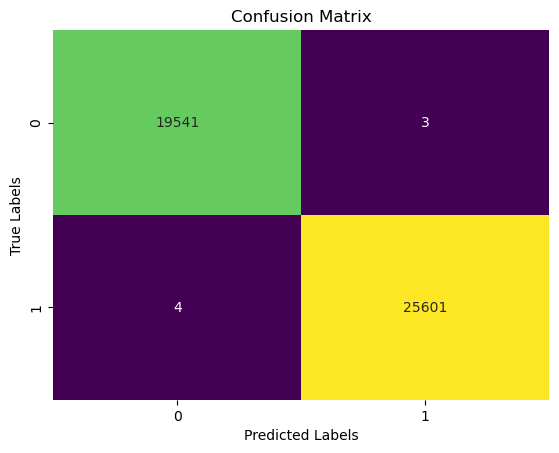

In [82]:
confMat = confusion_matrix(y_test,yPredHyperCatBoosting)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [83]:
print(format(classification_report(y_test,yPredHyperCatBoosting)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19544
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149



In [84]:
print("f1 Score {}".format(f1_score(y_test,yPredHyperCatBoosting)))
print("Recall Score {}".format(recall_score(y_test,yPredHyperCatBoosting)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredHyperCatBoosting)))
print("Precision Score {}".format(precision_score(y_test,yPredHyperCatBoosting)))

f1 Score 0.9998633052783691
Recall Score 0.9998437805116188
Accuracy Score 0.9998449578063745
Precision Score 0.9998828308076863


# LightGBM

In [85]:
lightGBM = LGBMClassifier()

In [86]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_samples': [20, 50, 100]
}

In [87]:
lgb_grid = RandomizedSearchCV(estimator=lightGBM,param_distributions=param_grid,cv=5,verbose=2,n_jobs=-1)

In [88]:
lgb_grid.fit(x,y)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 128027, number of negative: 97718
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005152 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2903
[LightGBM] [Info] Number of data points in the train set: 225745, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567131 -> initscore=0.270155
[LightGBM] [Info] Start training from score 0.270155
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

RandomizedSearchCV(cv=5, estimator=LGBMClassifier(), n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.5],
                                        'max_depth': [3, 5, 7],
                                        'min_child_samples': [20, 50, 100],
                                        'n_estimators': [50, 100, 200],
                                        'subsample': [0.8, 1.0]},
                   verbose=2)

In [89]:
print(lgb_grid.best_params_)

{'subsample': 0.8, 'n_estimators': 200, 'min_child_samples': 100, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [90]:
print(lgb_grid.best_score_)

0.9997076347205918


In [91]:
bestModelLightGBM = lgb_grid.best_estimator_

In [92]:
bestModelLightGBM.fit(x_train,y_train)

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 102422, number of negative: 78174
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005703 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2897
[LightGBM] [Info] Number of data points in the train set: 180596, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567133 -> initscore=0.270164
[LightGBM] [Info] Start training from score 0.270164
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

LGBMClassifier(colsample_bytree=0.8, max_depth=5, min_child_samples=100,
               n_estimators=200, subsample=0.8)

In [93]:
yPredHyperLightGBM = bestModelLightGBM.predict(x_test)

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).


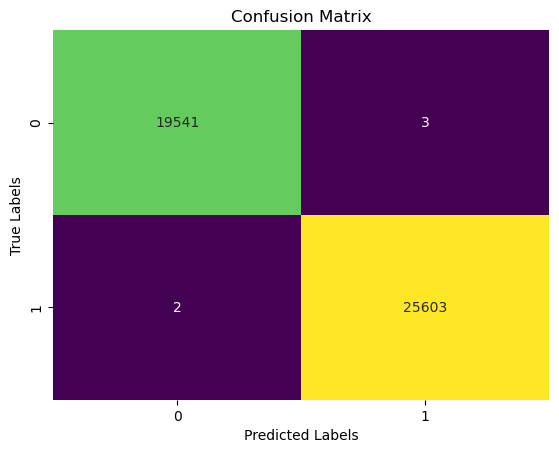

In [94]:
confMat = confusion_matrix(y_test,yPredHyperLightGBM)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [95]:
print(format(classification_report(y_test,yPredHyperLightGBM)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19544
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149



In [96]:
print("f1 Score {}".format(f1_score(y_test,yPredHyperLightGBM)))
print("Recall Score {}".format(recall_score(y_test,yPredHyperLightGBM)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredHyperLightGBM)))
print("Precision Score {}".format(precision_score(y_test,yPredHyperLightGBM)))

f1 Score 0.9999023647263283
Recall Score 0.9999218902558095
Accuracy Score 0.9998892555759817
Precision Score 0.9998828399593845


# AdaBoosting

In [97]:
adaBoosting = AdaBoostClassifier()

In [98]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'algorithm': ['SAMME', 'SAMME.R']
}

In [99]:
adb_grid = RandomizedSearchCV(estimator=adaBoosting,param_distributions=param_grid,cv=5,verbose=2,n_jobs=-1)

In [100]:
adb_grid.fit(x,y)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.



RandomizedSearchCV(cv=5, estimator=AdaBoostClassifier(), n_jobs=-1,
                   param_distributions={'algorithm': ['SAMME', 'SAMME.R'],
                                        'learning_rate': [0.01, 0.1, 0.5, 1.0],
                                        'n_estimators': [50, 100, 200]},
                   verbose=2)

In [101]:
print(adb_grid.best_params_)

{'n_estimators': 100, 'learning_rate': 1.0, 'algorithm': 'SAMME.R'}


In [102]:
print(adb_grid.best_score_)

0.9996899156127489


In [103]:
bestModelAdaBoost = adb_grid.best_estimator_

In [104]:
bestModelAdaBoost.fit(x_train,y_train)

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.



AdaBoostClassifier(n_estimators=100)

In [105]:
yPredHyperAdaBoost = bestModelAdaBoost.predict(x_test)

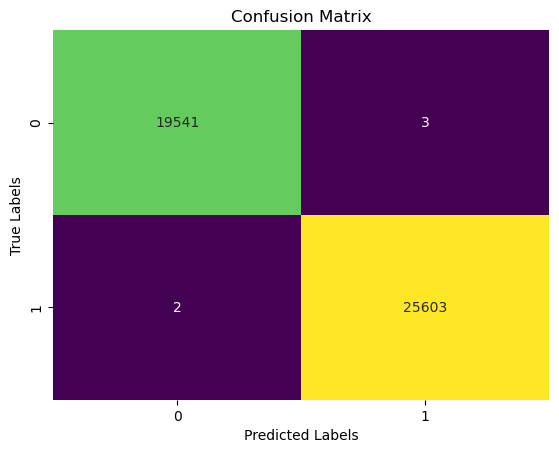

In [106]:
confMat = confusion_matrix(y_test,yPredHyperAdaBoost)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [107]:
print(format(classification_report(y_test,yPredHyperAdaBoost)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19544
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149



In [108]:
print("f1 Score {}".format(f1_score(y_test,yPredHyperAdaBoost)))
print("Recall Score {}".format(recall_score(y_test,yPredHyperAdaBoost)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredHyperAdaBoost)))
print("Precision Score {}".format(precision_score(y_test,yPredHyperAdaBoost)))

f1 Score 0.9999023647263283
Recall Score 0.9999218902558095
Accuracy Score 0.9998892555759817
Precision Score 0.9998828399593845


# XGBoost.

In [109]:
xGBoost = XGBClassifier()

In [110]:
param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.1, 0.01, 0.001],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_lambda': [0, 1, 10],
    'reg_alpha': [0, 1, 10]
}

In [111]:
xb_grid = RandomizedSearchCV(estimator=xGBoost, param_distributions=param_grid, cv=5, scoring='accuracy')

In [112]:
xb_grid.fit(x,y)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=None, ...),
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.1, 0.01, 0.001],
                                        'max_depth': [3, 6, 9],
                                        'n_estimators': [100, 200, 300],
                                        'reg_alpha': [0, 1, 10],
                                        'reg_lambda': [0, 1, 10],
                                        'subsample': [0.8, 0.9, 1.0]},
                   scoring='accuracy')

In [113]:
print(xb_grid.best_params_)

{'subsample': 0.9, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}


In [114]:
print(xb_grid.best_score_)

0.9996943453897096


In [115]:
bestModelXgBoost = xb_grid.best_estimator_

In [116]:
bestModelXgBoost.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [117]:
yPredHyperXgBoost = bestModelXgBoost.predict(x_test)

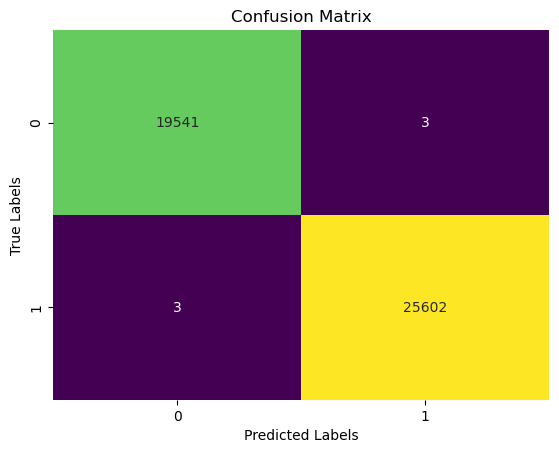

In [118]:
confMat = confusion_matrix(y_test,yPredHyperXgBoost)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [119]:
print(format(classification_report(y_test,yPredHyperXgBoost)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19544
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149



In [127]:
print("f1 Score {}".format(f1_score(y_test,yPredHyperXgBoost)))
print("Recall Score {}".format(recall_score(y_test,yPredHyperXgBoost)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredHyperXgBoost)))
print("Precision Score {}".format(precision_score(y_test,yPredHyperXgBoost)))

f1 Score 0.9998828353837141
Recall Score 0.9998828353837141
Accuracy Score 0.9998671066911781
Precision Score 0.9998828353837141


# Logistic Regression

In [125]:
logisticRegression = LogisticRegression()

In [126]:
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': np.logspace(-4, 4, 20),
    'solver': ['liblinear']  # For small datasets, 'liblinear' is usually a good choice
}

In [128]:
lr_grid = RandomizedSearchCV(estimator=logisticRegression, param_distributions=param_grid, cv=5, scoring='accuracy')

In [129]:
lr_grid.fit(x,y)

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning:

Liblinear failed

RandomizedSearchCV(cv=5, estimator=LogisticRegression(),
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear']},
                   scoring='accuracy')

In [130]:
print(lr_grid.best_params_)

{'solver': 'liblinear', 'penalty': 'l2', 'C': 10000.0}


In [131]:
print(lr_grid.best_score_)

0.9934217812133159


In [132]:
bestModelLogisticRegression = lr_grid.best_estimator_

In [133]:
bestModelLogisticRegression.fit(x_train,y_train)

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



LogisticRegression(C=10000.0, solver='liblinear')

In [134]:
yPredHyperLogisticRegression = bestModelLogisticRegression.predict(x_test)

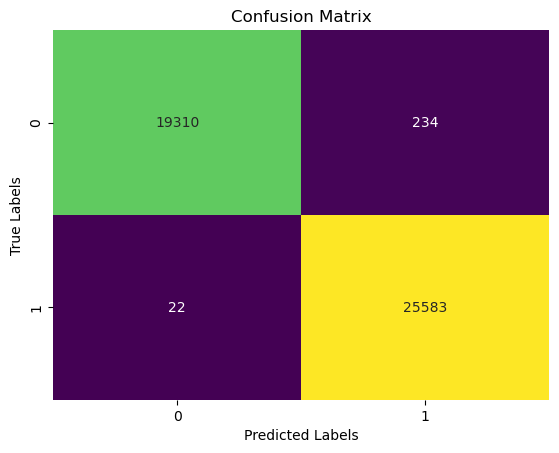

In [135]:
confMat = confusion_matrix(y_test,yPredHyperLogisticRegression)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [136]:
print(format(classification_report(y_test,yPredHyperLogisticRegression)))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     19544
           1       0.99      1.00      1.00     25605

    accuracy                           0.99     45149
   macro avg       0.99      0.99      0.99     45149
weighted avg       0.99      0.99      0.99     45149



In [137]:
print("f1 Score {}".format(f1_score(y_test,yPredHyperLogisticRegression)))
print("Recall Score {}".format(recall_score(y_test,yPredHyperLogisticRegression)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredHyperLogisticRegression)))
print("Precision Score {}".format(precision_score(y_test,yPredHyperLogisticRegression)))

f1 Score 0.9950215860915561
Recall Score 0.9991407928139036
Accuracy Score 0.9943298854902656
Precision Score 0.9909362048262773


   # Decision Tree

In [138]:
decisionTree = DecisionTreeClassifier()

In [139]:
param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

In [140]:
dt_grid = RandomizedSearchCV(estimator=decisionTree, param_distributions=param_grid, cv=5, scoring='accuracy')

In [141]:
dt_grid.fit(x,y)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(),
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 5, 7, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10]},
                   scoring='accuracy')

In [142]:
print(dt_grid.best_params_)

{'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'entropy'}


In [143]:
print(dt_grid.best_score_)

0.9996013200735343


In [144]:
bestModelDecisionTree = dt_grid.best_estimator_

In [145]:
bestModelDecisionTree.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_features='sqrt',
                       min_samples_leaf=4, min_samples_split=5)

In [146]:
yPredHyperDecisionTree = bestModelDecisionTree.predict(x_test)

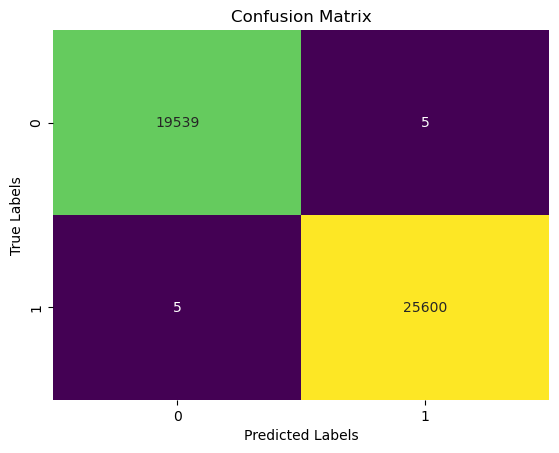

In [147]:
confMat = confusion_matrix(y_test,yPredHyperDecisionTree)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [148]:
print(format(classification_report(y_test,yPredHyperDecisionTree)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19544
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149



In [149]:
print("f1 Score {}".format(f1_score(y_test,yPredHyperDecisionTree)))
print("Recall Score {}".format(recall_score(y_test,yPredHyperDecisionTree)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredHyperDecisionTree)))
print("Precision Score {}".format(precision_score(y_test,yPredHyperDecisionTree)))

f1 Score 0.9998047256395235
Recall Score 0.9998047256395235
Accuracy Score 0.9997785111519635
Precision Score 0.9998047256395235


# Voting Classifier

In [28]:
votingRandomForest = RandomForestClassifier(n_estimators=200, min_samples_split=10, min_samples_leaf=1, max_features='sqrt', max_depth=None, bootstrap=True)
votingGradientBoosting = GradientBoostingClassifier(subsample=1.0, n_estimators=50, min_samples_split=2, min_samples_leaf=1, max_depth=3, learning_rate=0.1)
votingCatBoosting = CatBoostClassifier(learning_rate=0.1, l2_leaf_reg=9, depth=4)
votingLightGBM = LGBMClassifier(subsample=0.8, n_estimators=200, min_child_samples=50, max_depth=5, learning_rate=0.01, colsample_bytree=1.0)
votingAdaBoosting = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, algorithm='SAMME.R')
votingXGBoosting = XGBClassifier(subsample=0.9, reg_lambda=10, reg_alpha=0, n_estimators=100, max_depth=6, learning_rate=0.1, gamma=0.2, colsample_bytree=0.8)
votingLogisticRegression = LogisticRegression(solver='liblinear', penalty='l2', C=3792.690190732246)
votingDecisionTree = DecisionTreeClassifier(min_samples_split=5, min_samples_leaf=1, max_features='log2', max_depth=5, criterion='gini')

## Hard Voting

In [150]:
estimators = [("lgbm",bestModelLightGBM),("Gb",bestModel),("Lr",bestModelLogisticRegression),("Cb",bestModelCatBoosting),("Dt",bestModelDecisionTree),("Rf",bestModelRandomForest)]

In [151]:
ProcessVotingClassifier = VotingClassifier(estimators=estimators,voting='hard')
result = cross_val_score(ProcessVotingClassifier,x,y,cv=10,scoring='accuracy')

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 115224, number of negative: 87946
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010974 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2883
[LightGBM] [Info] Number of data points in the train set: 203170, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567131 -> initscore=0.270155
[LightGBM] [Info] Start training from score 0.270155
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

62:	learn: 0.0011956	total: 2.38s	remaining: 35.5s
63:	learn: 0.0011877	total: 2.41s	remaining: 35.3s
64:	learn: 0.0011803	total: 2.44s	remaining: 35.2s
65:	learn: 0.0011739	total: 2.48s	remaining: 35s
66:	learn: 0.0011622	total: 2.51s	remaining: 35s
67:	learn: 0.0011514	total: 2.55s	remaining: 34.9s
68:	learn: 0.0011436	total: 2.58s	remaining: 34.8s
69:	learn: 0.0011335	total: 2.62s	remaining: 34.8s
70:	learn: 0.0011301	total: 2.65s	remaining: 34.7s
71:	learn: 0.0011301	total: 2.68s	remaining: 34.6s
72:	learn: 0.0011299	total: 2.71s	remaining: 34.4s
73:	learn: 0.0011299	total: 2.74s	remaining: 34.3s
74:	learn: 0.0011299	total: 2.76s	remaining: 34.1s
75:	learn: 0.0011299	total: 2.79s	remaining: 33.9s
76:	learn: 0.0011255	total: 2.82s	remaining: 33.8s
77:	learn: 0.0011198	total: 2.86s	remaining: 33.8s
78:	learn: 0.0011101	total: 2.9s	remaining: 33.8s
79:	learn: 0.0011101	total: 2.92s	remaining: 33.6s
80:	learn: 0.0011080	total: 2.95s	remaining: 33.5s
81:	learn: 0.0011077	total: 2.98s	re

225:	learn: 0.0009552	total: 7.65s	remaining: 26.2s
226:	learn: 0.0009546	total: 7.69s	remaining: 26.2s
227:	learn: 0.0009546	total: 7.72s	remaining: 26.1s
228:	learn: 0.0009546	total: 7.75s	remaining: 26.1s
229:	learn: 0.0009546	total: 7.78s	remaining: 26s
230:	learn: 0.0009546	total: 7.81s	remaining: 26s
231:	learn: 0.0009546	total: 7.84s	remaining: 25.9s
232:	learn: 0.0009546	total: 7.87s	remaining: 25.9s
233:	learn: 0.0009546	total: 7.9s	remaining: 25.9s
234:	learn: 0.0009546	total: 7.93s	remaining: 25.8s
235:	learn: 0.0009546	total: 7.96s	remaining: 25.8s
236:	learn: 0.0009546	total: 7.99s	remaining: 25.7s
237:	learn: 0.0009545	total: 8.01s	remaining: 25.7s
238:	learn: 0.0009545	total: 8.04s	remaining: 25.6s
239:	learn: 0.0009545	total: 8.07s	remaining: 25.6s
240:	learn: 0.0009544	total: 8.11s	remaining: 25.5s
241:	learn: 0.0009488	total: 8.15s	remaining: 25.5s
242:	learn: 0.0009483	total: 8.18s	remaining: 25.5s
243:	learn: 0.0009487	total: 8.21s	remaining: 25.4s
244:	learn: 0.000

387:	learn: 0.0009184	total: 13.2s	remaining: 20.8s
388:	learn: 0.0009184	total: 13.2s	remaining: 20.7s
389:	learn: 0.0009184	total: 13.2s	remaining: 20.7s
390:	learn: 0.0009184	total: 13.3s	remaining: 20.7s
391:	learn: 0.0009184	total: 13.3s	remaining: 20.6s
392:	learn: 0.0009184	total: 13.3s	remaining: 20.6s
393:	learn: 0.0009184	total: 13.4s	remaining: 20.6s
394:	learn: 0.0009184	total: 13.4s	remaining: 20.5s
395:	learn: 0.0009184	total: 13.4s	remaining: 20.5s
396:	learn: 0.0009184	total: 13.5s	remaining: 20.5s
397:	learn: 0.0009184	total: 13.5s	remaining: 20.4s
398:	learn: 0.0009184	total: 13.5s	remaining: 20.4s
399:	learn: 0.0009184	total: 13.6s	remaining: 20.4s
400:	learn: 0.0009184	total: 13.6s	remaining: 20.3s
401:	learn: 0.0009184	total: 13.6s	remaining: 20.3s
402:	learn: 0.0009184	total: 13.7s	remaining: 20.2s
403:	learn: 0.0009184	total: 13.7s	remaining: 20.2s
404:	learn: 0.0009184	total: 13.7s	remaining: 20.2s
405:	learn: 0.0009184	total: 13.8s	remaining: 20.1s
406:	learn: 

...

327:	learn: 0.0008527	total: 10.9s	remaining: 22.2s
328:	learn: 0.0008525	total: 10.9s	remaining: 22.2s
329:	learn: 0.0008524	total: 10.9s	remaining: 22.2s
330:	learn: 0.0008525	total: 11s	remaining: 22.1s
331:	learn: 0.0008527	total: 11s	remaining: 22.1s
332:	learn: 0.0008527	total: 11s	remaining: 22.1s
333:	learn: 0.0008526	total: 11.1s	remaining: 22s
334:	learn: 0.0008526	total: 11.1s	remaining: 22s
335:	learn: 0.0008525	total: 11.1s	remaining: 22s
336:	learn: 0.0008525	total: 11.2s	remaining: 22s
337:	learn: 0.0008525	total: 11.2s	remaining: 21.9s
338:	learn: 0.0008523	total: 11.2s	remaining: 21.9s
339:	learn: 0.0008523	total: 11.3s	remaining: 21.9s
340:	learn: 0.0008524	total: 11.3s	remaining: 21.8s
341:	learn: 0.0008522	total: 11.3s	remaining: 21.8s
342:	learn: 0.0008525	total: 11.4s	remaining: 21.8s
343:	learn: 0.0008524	total: 11.4s	remaining: 21.7s
344:	learn: 0.0008524	total: 11.4s	remaining: 21.7s
345:	learn: 0.0008525	total: 11.5s	remaining: 21.7s
346:	learn: 0.0008525	tota

487:	learn: 0.0008523	total: 16.2s	remaining: 17s
488:	learn: 0.0008523	total: 16.2s	remaining: 17s
489:	learn: 0.0008523	total: 16.3s	remaining: 16.9s
490:	learn: 0.0008523	total: 16.3s	remaining: 16.9s
491:	learn: 0.0008523	total: 16.3s	remaining: 16.9s
492:	learn: 0.0008523	total: 16.4s	remaining: 16.8s
493:	learn: 0.0008523	total: 16.4s	remaining: 16.8s
494:	learn: 0.0008523	total: 16.4s	remaining: 16.8s
495:	learn: 0.0008523	total: 16.5s	remaining: 16.7s
496:	learn: 0.0008523	total: 16.5s	remaining: 16.7s
497:	learn: 0.0008523	total: 16.5s	remaining: 16.7s
498:	learn: 0.0008523	total: 16.6s	remaining: 16.6s
499:	learn: 0.0008523	total: 16.6s	remaining: 16.6s
500:	learn: 0.0008523	total: 16.6s	remaining: 16.6s
501:	learn: 0.0008523	total: 16.7s	remaining: 16.5s
502:	learn: 0.0008523	total: 16.7s	remaining: 16.5s
503:	learn: 0.0008523	total: 16.7s	remaining: 16.5s
504:	learn: 0.0008523	total: 16.8s	remaining: 16.4s
505:	learn: 0.0008523	total: 16.8s	remaining: 16.4s
506:	learn: 0.00

652:	learn: 0.0008523	total: 21.6s	remaining: 11.5s
653:	learn: 0.0008523	total: 21.7s	remaining: 11.5s
654:	learn: 0.0008523	total: 21.7s	remaining: 11.4s
655:	learn: 0.0008523	total: 21.7s	remaining: 11.4s
656:	learn: 0.0008523	total: 21.8s	remaining: 11.4s
657:	learn: 0.0008523	total: 21.8s	remaining: 11.3s
658:	learn: 0.0008523	total: 21.8s	remaining: 11.3s
659:	learn: 0.0008523	total: 21.9s	remaining: 11.3s
660:	learn: 0.0008523	total: 21.9s	remaining: 11.2s
661:	learn: 0.0008523	total: 21.9s	remaining: 11.2s
662:	learn: 0.0008523	total: 22s	remaining: 11.2s
663:	learn: 0.0008523	total: 22s	remaining: 11.1s
664:	learn: 0.0008523	total: 22s	remaining: 11.1s
665:	learn: 0.0008523	total: 22.1s	remaining: 11.1s
666:	learn: 0.0008523	total: 22.1s	remaining: 11s
667:	learn: 0.0008523	total: 22.1s	remaining: 11s
668:	learn: 0.0008523	total: 22.2s	remaining: 11s
669:	learn: 0.0008523	total: 22.2s	remaining: 10.9s
670:	learn: 0.0008523	total: 22.2s	remaining: 10.9s
671:	learn: 0.0008523	to

812:	learn: 0.0008523	total: 27.1s	remaining: 6.24s
813:	learn: 0.0008523	total: 27.1s	remaining: 6.2s
814:	learn: 0.0008523	total: 27.2s	remaining: 6.17s
815:	learn: 0.0008523	total: 27.2s	remaining: 6.14s
816:	learn: 0.0008523	total: 27.3s	remaining: 6.11s
817:	learn: 0.0008523	total: 27.3s	remaining: 6.07s
818:	learn: 0.0008523	total: 27.3s	remaining: 6.04s
819:	learn: 0.0008523	total: 27.4s	remaining: 6.01s
820:	learn: 0.0008523	total: 27.4s	remaining: 5.98s
821:	learn: 0.0008523	total: 27.4s	remaining: 5.94s
822:	learn: 0.0008523	total: 27.5s	remaining: 5.91s
823:	learn: 0.0008523	total: 27.5s	remaining: 5.88s
824:	learn: 0.0008523	total: 27.5s	remaining: 5.84s
825:	learn: 0.0008523	total: 27.6s	remaining: 5.81s
826:	learn: 0.0008523	total: 27.6s	remaining: 5.78s
827:	learn: 0.0008523	total: 27.6s	remaining: 5.74s
828:	learn: 0.0008523	total: 27.7s	remaining: 5.71s
829:	learn: 0.0008523	total: 27.7s	remaining: 5.67s
830:	learn: 0.0008523	total: 27.7s	remaining: 5.64s
831:	learn: 0

977:	learn: 0.0008523	total: 32.5s	remaining: 732ms
978:	learn: 0.0008523	total: 32.6s	remaining: 699ms
979:	learn: 0.0008523	total: 32.6s	remaining: 665ms
980:	learn: 0.0008523	total: 32.6s	remaining: 632ms
981:	learn: 0.0008523	total: 32.7s	remaining: 599ms
982:	learn: 0.0008523	total: 32.7s	remaining: 565ms
983:	learn: 0.0008523	total: 32.7s	remaining: 532ms
984:	learn: 0.0008523	total: 32.8s	remaining: 499ms
985:	learn: 0.0008523	total: 32.8s	remaining: 466ms
986:	learn: 0.0008523	total: 32.8s	remaining: 432ms
987:	learn: 0.0008523	total: 32.9s	remaining: 399ms
988:	learn: 0.0008523	total: 32.9s	remaining: 366ms
989:	learn: 0.0008523	total: 32.9s	remaining: 333ms
990:	learn: 0.0008523	total: 33s	remaining: 299ms
991:	learn: 0.0008523	total: 33s	remaining: 266ms
992:	learn: 0.0008523	total: 33s	remaining: 233ms
993:	learn: 0.0008523	total: 33.1s	remaining: 200ms
994:	learn: 0.0008523	total: 33.1s	remaining: 166ms
995:	learn: 0.0008523	total: 33.1s	remaining: 133ms
996:	learn: 0.0008

In [152]:
print(np.mean(result)*100)

99.97120604747118


## Soft Voting

In [153]:
ProcessVotingClassifier = VotingClassifier(estimators=estimators,voting='soft')
result1 = cross_val_score(ProcessVotingClassifier,x,y,cv=5,scoring='accuracy')

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 102422, number of negative: 78174
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011320 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2865
[LightGBM] [Info] Number of data points in the train set: 180596, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567133 -> initscore=0.270164
[LightGBM] [Info] Start training from score 0.270164
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



0:	learn: 0.5047553	total: 34.6ms	remaining: 34.6s
1:	learn: 0.3751165	total: 72ms	remaining: 35.9s
2:	learn: 0.2822283	total: 115ms	remaining: 38.3s
3:	learn: 0.2068935	total: 150ms	remaining: 37.4s
4:	learn: 0.1526476	total: 186ms	remaining: 37s
5:	learn: 0.1133132	total: 220ms	remaining: 36.4s
6:	learn: 0.0839801	total: 265ms	remaining: 37.6s
7:	learn: 0.0642005	total: 303ms	remaining: 37.6s
8:	learn: 0.0485785	total: 344ms	remaining: 37.8s
9:	learn: 0.0380238	total: 384ms	remaining: 38s
10:	learn: 0.0305953	total: 425ms	remaining: 38.2s
11:	learn: 0.0241733	total: 469ms	remaining: 38.6s
12:	learn: 0.0193712	total: 521ms	remaining: 39.6s
13:	learn: 0.0159429	total: 567ms	remaining: 39.9s
14:	learn: 0.0132935	total: 613ms	remaining: 40.3s
15:	learn: 0.0111741	total: 662ms	remaining: 40.7s
16:	learn: 0.0093928	total: 711ms	remaining: 41.1s
17:	learn: 0.0080538	total: 761ms	remaining: 41.5s
18:	learn: 0.0070953	total: 808ms	remaining: 41.7s
19:	learn: 0.0063992	total: 854ms	remaining: 

167:	learn: 0.0009989	total: 5.43s	remaining: 26.9s
168:	learn: 0.0009989	total: 5.46s	remaining: 26.8s
169:	learn: 0.0009989	total: 5.49s	remaining: 26.8s
170:	learn: 0.0009990	total: 5.51s	remaining: 26.7s
171:	learn: 0.0009986	total: 5.54s	remaining: 26.7s
172:	learn: 0.0009988	total: 5.57s	remaining: 26.6s
173:	learn: 0.0009988	total: 5.59s	remaining: 26.6s
174:	learn: 0.0009988	total: 5.62s	remaining: 26.5s
175:	learn: 0.0009988	total: 5.65s	remaining: 26.5s
176:	learn: 0.0009988	total: 5.68s	remaining: 26.4s
177:	learn: 0.0009988	total: 5.71s	remaining: 26.4s
178:	learn: 0.0009988	total: 5.74s	remaining: 26.3s
179:	learn: 0.0009988	total: 5.76s	remaining: 26.3s
180:	learn: 0.0009989	total: 5.79s	remaining: 26.2s
181:	learn: 0.0009990	total: 5.82s	remaining: 26.2s
182:	learn: 0.0009988	total: 5.85s	remaining: 26.1s
183:	learn: 0.0009988	total: 5.88s	remaining: 26.1s
184:	learn: 0.0009988	total: 5.91s	remaining: 26s
185:	learn: 0.0009988	total: 5.93s	remaining: 26s
186:	learn: 0.00

...

323:	learn: 0.0008379	total: 10.2s	remaining: 21.2s
324:	learn: 0.0008379	total: 10.2s	remaining: 21.2s
325:	learn: 0.0008379	total: 10.2s	remaining: 21.2s
326:	learn: 0.0008379	total: 10.3s	remaining: 21.1s
327:	learn: 0.0008379	total: 10.3s	remaining: 21.1s
328:	learn: 0.0008379	total: 10.3s	remaining: 21.1s
329:	learn: 0.0008379	total: 10.4s	remaining: 21s
330:	learn: 0.0008379	total: 10.4s	remaining: 21s
331:	learn: 0.0008379	total: 10.4s	remaining: 21s
332:	learn: 0.0008379	total: 10.5s	remaining: 21s
333:	learn: 0.0008379	total: 10.5s	remaining: 20.9s
334:	learn: 0.0008379	total: 10.5s	remaining: 20.9s
335:	learn: 0.0008379	total: 10.6s	remaining: 20.9s
336:	learn: 0.0008379	total: 10.6s	remaining: 20.8s
337:	learn: 0.0008379	total: 10.6s	remaining: 20.8s
338:	learn: 0.0008379	total: 10.7s	remaining: 20.8s
339:	learn: 0.0008379	total: 10.7s	remaining: 20.7s
340:	learn: 0.0008379	total: 10.7s	remaining: 20.7s
341:	learn: 0.0008379	total: 10.7s	remaining: 20.7s
342:	learn: 0.000837

482:	learn: 0.0008379	total: 15.3s	remaining: 16.4s
483:	learn: 0.0008379	total: 15.3s	remaining: 16.3s
484:	learn: 0.0008379	total: 15.4s	remaining: 16.3s
485:	learn: 0.0008379	total: 15.4s	remaining: 16.3s
486:	learn: 0.0008379	total: 15.4s	remaining: 16.3s
487:	learn: 0.0008379	total: 15.5s	remaining: 16.2s
488:	learn: 0.0008379	total: 15.5s	remaining: 16.2s
489:	learn: 0.0008379	total: 15.5s	remaining: 16.2s
490:	learn: 0.0008379	total: 15.6s	remaining: 16.1s
491:	learn: 0.0008379	total: 15.6s	remaining: 16.1s
492:	learn: 0.0008379	total: 15.6s	remaining: 16.1s
493:	learn: 0.0008379	total: 15.6s	remaining: 16s
494:	learn: 0.0008379	total: 15.7s	remaining: 16s
495:	learn: 0.0008379	total: 15.7s	remaining: 16s
496:	learn: 0.0008379	total: 15.7s	remaining: 15.9s
497:	learn: 0.0008379	total: 15.8s	remaining: 15.9s
498:	learn: 0.0008379	total: 15.8s	remaining: 15.9s
499:	learn: 0.0008379	total: 15.8s	remaining: 15.8s
500:	learn: 0.0008379	total: 15.9s	remaining: 15.8s
501:	learn: 0.0008

643:	learn: 0.0008379	total: 20.4s	remaining: 11.3s
644:	learn: 0.0008379	total: 20.4s	remaining: 11.3s
645:	learn: 0.0008379	total: 20.5s	remaining: 11.2s
646:	learn: 0.0008379	total: 20.5s	remaining: 11.2s
647:	learn: 0.0008379	total: 20.5s	remaining: 11.2s
648:	learn: 0.0008379	total: 20.6s	remaining: 11.1s
649:	learn: 0.0008379	total: 20.6s	remaining: 11.1s
650:	learn: 0.0008379	total: 20.6s	remaining: 11.1s
651:	learn: 0.0008379	total: 20.7s	remaining: 11s
652:	learn: 0.0008379	total: 20.7s	remaining: 11s
653:	learn: 0.0008379	total: 20.7s	remaining: 11s
654:	learn: 0.0008379	total: 20.8s	remaining: 10.9s
655:	learn: 0.0008379	total: 20.8s	remaining: 10.9s
656:	learn: 0.0008379	total: 20.8s	remaining: 10.9s
657:	learn: 0.0008379	total: 20.9s	remaining: 10.8s
658:	learn: 0.0008379	total: 20.9s	remaining: 10.8s
659:	learn: 0.0008379	total: 20.9s	remaining: 10.8s
660:	learn: 0.0008379	total: 20.9s	remaining: 10.7s
661:	learn: 0.0008379	total: 21s	remaining: 10.7s
662:	learn: 0.000837

802:	learn: 0.0008379	total: 25.6s	remaining: 6.27s
803:	learn: 0.0008379	total: 25.6s	remaining: 6.24s
804:	learn: 0.0008379	total: 25.6s	remaining: 6.21s
805:	learn: 0.0008379	total: 25.7s	remaining: 6.17s
806:	learn: 0.0008379	total: 25.7s	remaining: 6.14s
807:	learn: 0.0008379	total: 25.7s	remaining: 6.11s
808:	learn: 0.0008379	total: 25.7s	remaining: 6.08s
809:	learn: 0.0008379	total: 25.8s	remaining: 6.05s
810:	learn: 0.0008379	total: 25.8s	remaining: 6.01s
811:	learn: 0.0008379	total: 25.8s	remaining: 5.98s
812:	learn: 0.0008379	total: 25.9s	remaining: 5.95s
813:	learn: 0.0008379	total: 25.9s	remaining: 5.92s
814:	learn: 0.0008379	total: 25.9s	remaining: 5.89s
815:	learn: 0.0008379	total: 26s	remaining: 5.85s
816:	learn: 0.0008379	total: 26s	remaining: 5.82s
817:	learn: 0.0008379	total: 26s	remaining: 5.79s
818:	learn: 0.0008379	total: 26.1s	remaining: 5.76s
819:	learn: 0.0008379	total: 26.1s	remaining: 5.73s
820:	learn: 0.0008379	total: 26.1s	remaining: 5.7s
821:	learn: 0.00083

963:	learn: 0.0008379	total: 30.7s	remaining: 1.15s
964:	learn: 0.0008379	total: 30.7s	remaining: 1.11s
965:	learn: 0.0008379	total: 30.7s	remaining: 1.08s
966:	learn: 0.0008379	total: 30.8s	remaining: 1.05s
967:	learn: 0.0008379	total: 30.8s	remaining: 1.02s
968:	learn: 0.0008379	total: 30.8s	remaining: 986ms
969:	learn: 0.0008379	total: 30.9s	remaining: 954ms
970:	learn: 0.0008379	total: 30.9s	remaining: 923ms
971:	learn: 0.0008379	total: 30.9s	remaining: 891ms
972:	learn: 0.0008379	total: 31s	remaining: 859ms
973:	learn: 0.0008379	total: 31s	remaining: 827ms
974:	learn: 0.0008379	total: 31s	remaining: 795ms
975:	learn: 0.0008379	total: 31s	remaining: 763ms
976:	learn: 0.0008379	total: 31.1s	remaining: 732ms
977:	learn: 0.0008379	total: 31.1s	remaining: 700ms
978:	learn: 0.0008379	total: 31.1s	remaining: 668ms
979:	learn: 0.0008379	total: 31.2s	remaining: 636ms
980:	learn: 0.0008379	total: 31.2s	remaining: 605ms
981:	learn: 0.0008379	total: 31.2s	remaining: 573ms
982:	learn: 0.000837

In [154]:
print(np.mean(result1)*100)

99.97076347205918


## Stacking

In [155]:
StackEstimetors = [("Lr",bestModelLogisticRegression),("Dt",bestModelDecisionTree),("Rf",bestModelRandomForest),("Cb",bestModelCatBoosting),("Lgbm",bestModelLightGBM)]

In [156]:
ProcessStacking = StackingClassifier(estimators=StackEstimetors,final_estimator=bestModel,cv=5)

In [157]:
ProcessStacking.fit(x_train,y_train)

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



0:	learn: 0.5424377	total: 36.3ms	remaining: 36.3s
1:	learn: 0.3995928	total: 73.3ms	remaining: 36.6s
2:	learn: 0.2926191	total: 109ms	remaining: 36.2s
3:	learn: 0.2153618	total: 143ms	remaining: 35.6s
4:	learn: 0.1583727	total: 178ms	remaining: 35.4s
5:	learn: 0.1184574	total: 213ms	remaining: 35.3s
6:	learn: 0.0884257	total: 251ms	remaining: 35.6s
7:	learn: 0.0665727	total: 295ms	remaining: 36.6s
8:	learn: 0.0508138	total: 333ms	remaining: 36.7s
9:	learn: 0.0396259	total: 370ms	remaining: 36.6s
10:	learn: 0.0311051	total: 408ms	remaining: 36.7s
11:	learn: 0.0250806	total: 446ms	remaining: 36.7s
12:	learn: 0.0201976	total: 491ms	remaining: 37.3s
13:	learn: 0.0165804	total: 528ms	remaining: 37.2s
14:	learn: 0.0138152	total: 566ms	remaining: 37.2s
15:	learn: 0.0115046	total: 602ms	remaining: 37s
16:	learn: 0.0097308	total: 637ms	remaining: 36.8s
17:	learn: 0.0082966	total: 672ms	remaining: 36.7s
18:	learn: 0.0071904	total: 709ms	remaining: 36.6s
19:	learn: 0.0063267	total: 751ms	remaini

166:	learn: 0.0010849	total: 5.48s	remaining: 27.3s
167:	learn: 0.0010850	total: 5.51s	remaining: 27.3s
168:	learn: 0.0010849	total: 5.54s	remaining: 27.2s
169:	learn: 0.0010848	total: 5.57s	remaining: 27.2s
170:	learn: 0.0010851	total: 5.6s	remaining: 27.1s
171:	learn: 0.0010848	total: 5.63s	remaining: 27.1s
172:	learn: 0.0010854	total: 5.65s	remaining: 27s
173:	learn: 0.0010849	total: 5.68s	remaining: 27s
174:	learn: 0.0010849	total: 5.71s	remaining: 26.9s
175:	learn: 0.0010849	total: 5.74s	remaining: 26.9s
176:	learn: 0.0010849	total: 5.77s	remaining: 26.8s
177:	learn: 0.0010849	total: 5.8s	remaining: 26.8s
178:	learn: 0.0010849	total: 5.83s	remaining: 26.7s
179:	learn: 0.0010849	total: 5.85s	remaining: 26.7s
180:	learn: 0.0010849	total: 5.88s	remaining: 26.6s
181:	learn: 0.0010849	total: 5.91s	remaining: 26.6s
182:	learn: 0.0010849	total: 5.94s	remaining: 26.5s
183:	learn: 0.0010820	total: 5.97s	remaining: 26.5s
184:	learn: 0.0010820	total: 6s	remaining: 26.4s
185:	learn: 0.0010820

327:	learn: 0.0010094	total: 10.3s	remaining: 21s
328:	learn: 0.0010094	total: 10.3s	remaining: 21s
329:	learn: 0.0010094	total: 10.3s	remaining: 21s
330:	learn: 0.0010094	total: 10.4s	remaining: 20.9s
331:	learn: 0.0010094	total: 10.4s	remaining: 20.9s
332:	learn: 0.0010094	total: 10.4s	remaining: 20.9s
333:	learn: 0.0010094	total: 10.5s	remaining: 20.8s
334:	learn: 0.0010094	total: 10.5s	remaining: 20.8s
335:	learn: 0.0010094	total: 10.5s	remaining: 20.8s
336:	learn: 0.0010094	total: 10.5s	remaining: 20.7s
337:	learn: 0.0010094	total: 10.6s	remaining: 20.7s
338:	learn: 0.0010094	total: 10.6s	remaining: 20.7s
339:	learn: 0.0010094	total: 10.6s	remaining: 20.6s
340:	learn: 0.0010094	total: 10.6s	remaining: 20.6s
341:	learn: 0.0010094	total: 10.7s	remaining: 20.5s
342:	learn: 0.0010094	total: 10.7s	remaining: 20.5s
343:	learn: 0.0010094	total: 10.7s	remaining: 20.5s
344:	learn: 0.0010094	total: 10.8s	remaining: 20.4s
345:	learn: 0.0010094	total: 10.8s	remaining: 20.4s
346:	learn: 0.0010

490:	learn: 0.0010094	total: 14.9s	remaining: 15.4s
491:	learn: 0.0010094	total: 14.9s	remaining: 15.4s
492:	learn: 0.0010094	total: 14.9s	remaining: 15.4s
493:	learn: 0.0010094	total: 15s	remaining: 15.3s
494:	learn: 0.0010094	total: 15s	remaining: 15.3s
495:	learn: 0.0010094	total: 15s	remaining: 15.3s
496:	learn: 0.0010094	total: 15.1s	remaining: 15.2s
497:	learn: 0.0010094	total: 15.1s	remaining: 15.2s
498:	learn: 0.0010094	total: 15.1s	remaining: 15.2s
499:	learn: 0.0010094	total: 15.1s	remaining: 15.1s
500:	learn: 0.0010094	total: 15.2s	remaining: 15.1s
501:	learn: 0.0010094	total: 15.2s	remaining: 15.1s
502:	learn: 0.0010094	total: 15.2s	remaining: 15s
503:	learn: 0.0010094	total: 15.3s	remaining: 15s
504:	learn: 0.0010094	total: 15.3s	remaining: 15s
505:	learn: 0.0010094	total: 15.3s	remaining: 14.9s
506:	learn: 0.0010094	total: 15.3s	remaining: 14.9s
507:	learn: 0.0010094	total: 15.4s	remaining: 14.9s
508:	learn: 0.0010094	total: 15.4s	remaining: 14.9s
509:	learn: 0.0010094	to

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 81937, number of negative: 62540
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005506 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2885
[LightGBM] [Info] Number of data points in the train set: 144477, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567128 -> initscore=0.270144
[LightGBM] [Info] Start training from score 0.270144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

StackingClassifier(cv=5,
                   estimators=[('Lr',
                                LogisticRegression(C=10000.0,
                                                   solver='liblinear')),
                               ('Dt',
                                DecisionTreeClassifier(criterion='entropy',
                                                       max_features='sqrt',
                                                       min_samples_leaf=4,
                                                       min_samples_split=5)),
                               ('Rf',
                                RandomForestClassifier(max_features='log2')),
                               ('Cb',
                                <catboost.core.CatBoostClassifier object at 0x0000021BE19D9550>),
                               ('Lgbm',
                                LGBMClassifier(colsample_bytree=0.8,
                                               max_depth=5,
                                               min_child_samples=100,
                                               n_estimators=200,
                                               subsample=0.8))],
                   final_estimator=GradientBoostingClassifier(learning_rate=0.5,
                                                              max_depth=7,
                                                              min_samples_leaf=2,
                                                              min_samples_split=5,
                                                              n_estimators=200))

In [158]:
yPredStacking = ProcessStacking.predict(x_test)

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).


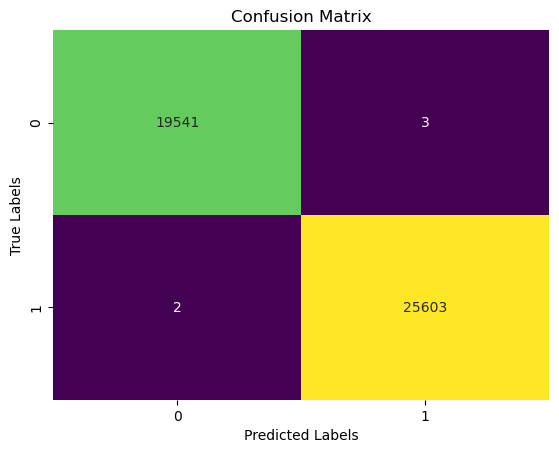

In [159]:
confMat = confusion_matrix(y_test,yPredStacking)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [160]:
print(format(classification_report(y_test,yPredStacking)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19544
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149



In [161]:
print("f1 Score {}".format(f1_score(y_test,yPredStacking)))
print("Recall Score {}".format(recall_score(y_test,yPredStacking)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredStacking)))
print("Precision Score {}".format(precision_score(y_test,yPredStacking)))

f1 Score 0.9999023647263283
Recall Score 0.9999218902558095
Accuracy Score 0.9998892555759817
Precision Score 0.9998828399593845
